## **SUMMARY**
This script is used to attribute national point data (NSI and HIFLD) into building footprints. Preprocessing of footprint, NSI, and HIFLD data is conducted in separate scripts.


In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
import pandas as pd
import geopandas as gpd
import os
import sys
import matplotlib.pyplot as plt
import folium
import contextily as ctx
import numpy as np

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns
import functions_point_to_ftpt as pt_ftpt
import functions_disagreement_and_gaps as resolve

In [3]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS FOR PLOTTING 
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

In [4]:
### DEFINE DIRECTORIES FOR ANALYSIS ###

# Target Directory 
directory = './Inventory_Outputs/Best_Estimate/' 

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_attribution = directory + 'FootprintAttribution/'
dir_intermediate = dir_attribution + 'Intermediate/'
os.makedirs(dir_intermediate, exist_ok=True)


# Required Previous Directories
previous_national_directory = './Inventory_Outputs/Synthesized_National/'
local_directory = './Inventory_Outputs/Synthesized_Local/'


# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)

## **Load Baseline Geometry (Footprints) and Bounding Geometry (Census Blocks)**

In [5]:
# Load building footprints 
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)

# Load Census blocks and tracts
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2020/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2020/Hayward_tracts.geojson')

# Create CensusBlock column 
hayward_blocks['CensusBlock'] = hayward_blocks['GEOID20'] 

## **Update Footprints Using Local Data for Updated NSI Footprint Merge**

In [6]:
# Load data that has previously been attributed to building footprints (using prior scripts)
nsi = fxns.json_to_gdf(previous_national_directory + '/FootprintAttribution/National_Inventory_Point.json', crs_main)
tax = fxns.json_to_gdf(local_directory + '/FootprintAttribution/All_Local_Data_Attributed.json', crs_main)


### FIRST: POINTS THAT DO NOT HAVE FOOTPRINTS ### 

# Extract points with no footprints  
no_ftpt = tax[tax['Footprint_Flag']==0].copy()

# Create circle geometries with 5m radius around each point 
no_ftpt['geometry'] = no_ftpt.geometry.buffer(5)
no_ftpt = no_ftpt.set_geometry('geometry')
no_ftpt = no_ftpt.set_crs(footprints.crs)
# print(len(no_ftpt))

# Append gdfs together 
no_ftpt = no_ftpt[['FootprintID','geometry', 'FootprintArea', 'FootprintHeight', 'CensusBlock', 'CensusTract']]
ftpt_augmented = pd.concat([footprints, no_ftpt], ignore_index = True)


### SECOND: FOOTPRINTS THAT HAVE RESIDENTIAL NSI DATA, BUT NO CORRESPONDING TAX DATA ### 

# Drop columns that are shared between rows 
tax = tax.drop(columns = ['geometry', 'ftpt_geometry', 'FootprintArea', 'FootprintHeight', 'CensusBlock', 'CensusTract', 'Footprint_Flag'])

# Merge Data based on FootprintID and check no data is lost
alldata = gpd.GeoDataFrame(nsi.merge(tax, on='FootprintID', how='left'))
alldata['Local_Flag'] = alldata['Local_Flag'].fillna(0)
if (len(nsi) != len(alldata)):
    raise ValueError('Footprint data lost in merge')

# Find footprints that has residential NSI data, but no corresponding tax data 
nsi_only = alldata[(alldata['National_Flag']==1) & (alldata['Local_Flag']==0)]
res_types = ['RES1-1SNB', 'RES1-1SWB', 'RES1-2SNB', 'RES1-2SWB', 'RES1-3SNB', 'RES1-3SWB', 'RES1-SLNB', 'RES1-SLWB', 'RES1', 'RES2',' RES3A', 'RES3B', 'RES3C', 'RES3D','RES3E', 'RES3F']
res_nsi_only = nsi_only[nsi_only['NSI_OccupancyClass'].apply(resolve.check_occupancy_class, args=(res_types,))]
res_nsi_only_ftpts = res_nsi_only['FootprintID'].tolist()

# Mark footprints to remove from updated NSI merge 
ftpt_augmented['Remove_Footprint_Flag'] = 0
ftpt_augmented.loc[ftpt_augmented['FootprintID'].isin(res_nsi_only_ftpts), 'Remove_Footprint_Flag'] = 1


### THIRD: FOOTPRINTS THAT DO NOT HAVE NSI OR TAX DATA ###  

# Mark footprints to remove from updated NSI merge - this functionally forces NSI data into footprints with residential tax data where relevant 
only_ftpt = alldata[(alldata['Footprint_Flag']==1) & (alldata['National_Flag']==0) & (alldata['Local_Flag']==0)]
only_ftpt_ids = only_ftpt['FootprintID'].tolist()
ftpt_augmented.loc[ftpt_augmented['FootprintID'].isin(only_ftpt_ids), 'Remove_Footprint_Flag'] = 1

### EXPORT DATA FOR USE IN NSI MERGE ###
if len(ftpt_augmented) != (len(footprints) + len(no_ftpt)):
    raise ValueError('Footprint Data Dropped')
fxns.gdf_to_json(ftpt_augmented, './Input_Data/ProcessedFootprints/Hayward_Footprints_AUGMENTED.json')


JSON File Saved


In [7]:
# ## UNCOMMENT TO PLOT FOOTPRINTS BEING DROPPED AND AUGMENTED FOOTPRINT CIRCLES
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)
# folium.GeoJson(ftpt_augmented[ftpt_augmented['Remove_Footprint_Flag']==1].copy().to_crs(crs_plot), color = 'red').add_to(m)
# folium.GeoJson(no_ftpt.copy().to_crs(crs_plot), color = 'green').add_to(m)
# folium.GeoJson(ftpt_augmented[ftpt_augmented['FootprintID'].isin(only_ftpt_ids)].copy().to_crs(crs_plot), color = 'orange').add_to(m)
# # display(m)

# import webbrowser
# html_path = "footprints_map.html"
# m.save(html_path)
# webbrowser.open("file://" + os.path.abspath(html_path))

## **Attribute Points to Footprints**

In [8]:
## SETTINGS FOR "NOT FULL FOOTPRINT" DESIGNATION DURING MERGE PROCESS
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints_AUGMENTED.json', crs_main)

# Filter footprints by their use flag (remove footprints marked to be dropped by data comparison)
print('Total Footprints:', len(footprints))
footprints = footprints[footprints['Remove_Footprint_Flag']==0].copy()
print('Footprints in Use:', len(footprints))

# Compute square footage to be used for "not full footprint" designation during merge process
    # If most footprints have FootprintHeight available (in feet), set estimate_stories = True
    # If most footprints do not have FootprintHeight available, using height to designate if a footprint is not full may cause bias, and it is better to just use FootprintArea (set estimate_stories = False)
estimate_stories = True
footprints = pt_ftpt.estimate_ftpt_size_for_merge(footprints.copy(),estimate_stories)

Total Footprints: 38510
Footprints in Use: 35613


In [9]:
##### LOAD PREPROCESSED DATA FOR MERGE #####
points = fxns.json_to_gdf('./Input_Data/ProcessedData/National/NSI_for_Merge_with_CA_Data.json', crs_main)
##### DISPLAY NUMBER OF POINTS #####
points_length = len(points) # Used for tracking purposes 
print('NSI:', len(points))
print('Footprints:', len(footprints))


NSI: 38479
Footprints: 35613


In [10]:
### DEFINE COLUMNS TO BE SUMMED OR COVERTED TO LISTS WHEN COMBINED ### 
# sum_columns get summed when points are merged (i.e. replacement cost)
# list_columns get put into lists (if information differs) when points are merged (i.e. foundation type)

# Set category of certain column names
excluded = ['geometry', 'CensusBlock', 'CensusTract', 'POINT_ID', 'NSI_OccupancyClass', 'POINT_DropFlag', 'POINT_DropNote', 'NSI_OC_Update',
            'POINT_FootprintID', 'DistanceToFtpt', 'ClosestFtpt_ID', 'POINT_MergeFlag','POINT_DataUpdate']
sum_columns = ['NSI_PopOver65_Day', 'NSI_PopUnder65_Day', 'NSI_Population_Day',
                    'NSI_PopOver65_Night', 'NSI_PopUnder65_Night', 'NSI_Population_Night','NSI_ContentValue','NSI_ReplacementCost',
                    'NSI_StructureValue','NSI_MinResUnits', 'NSI_MaxResUnits','POINT_NumPoints']
list_columns = ['NSI_FoundationType','NSI_FoundationHeight','NSI_BuildingType','NSI_MedYearBuilt',
                'NSI_NumberOfStories', 'POINT_Source', 'NSI_OrigSource', 'NSI_OrigFtptSource','NSI_BID','POINT_ID_List','NSI_TotalAreaSqFt']


# Check that all columns are assigned to a category
fxns.check_column_assignment(points, sum_columns, list_columns, excluded)


NSI_Units is unassigned
NSI_Students is unassigned


In [11]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in points.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

### **MergeFlag1 - Address Cases with 1 Footprint and 1 Point**

In [12]:
##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1] # Dropped - these should not be used in merge 


##### RUN FUNCTION TO MERGE CASES WITH ONE POINT WITHIN ONE FOOTPRINT #####
points0, map = pt_ftpt.merge_intersecting(points0, footprints, crs_plot)

# Plot overlapping footprints if found 
if isinstance(map, str):
    print(map)
else: 
    display(map)

# Update MergeFlag99 for footprints that are larger than their designated occupancy type 
points0 = pt_ftpt.update_mergeflag99(points0, footprints, mergeflag = 1)

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = pt_ftpt.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
pt_ftpt.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag1.json')


Points within Footprints: 34263
Unique points within Footprints (one point per footprint): 33540
Data with Associated Footprints (should match row above): 33540
Passed Check: No overlapping footprints found
Passed Check: No duplicates found
JSON File Saved


In [13]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag1.json', crs_main)
remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
print(len(remaining))

# Create a base map
m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# Add footprints (polygons)
folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# Add remaining points     
for idx, row in remaining.copy().to_crs(crs_plot).iterrows():
    folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
                        radius=1, 
                        color='blue', 
                        fill=True, 
                        fill_color='blue').add_to(m)

# display(m)

1670


### **MergeFlag2 - Address Cases with 1 Footprint and Multiple Points**

In [14]:
##### LOAD DATA #####
points = fxns.json_to_gdf(dir_intermediate + 'MergeFlag1.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "POINT_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
points = pt_ftpt.drop_ids(points, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1] # Dropped - these should not be used in merge 


#### RUN FUNCTION TO MERGE CASES WITH MULTIPLE POINTS WITHIN ONE FOOTPRINT #####
# Set flag to print odd occupancy pairings, including (RES + IND), (RES + GOV), and (EDU + IND) - does not change function outputs, only displays 
print_odd_occupancy_pairings = False
use_size_limit = True 
use_nsi_occupancy_merge = True # Set to true if points df consists of NSI data
points0 = pt_ftpt.address_overlapping_points(points0.copy(), footprints.copy(), list_columns, sum_columns, manually_assigned_occupancy,use_size_limit, use_nsi_occupancy_merge, print_odd_occupancy_pairings, crs_plot)

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = pt_ftpt.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
pt_ftpt.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag2.json')

Number of Points Remaining: 1670
Number of Footprints Remaining: 2073
Number of Points within Footprint Polygons: 774
Number of Footprints with Multiple Points (Looping Through These Now): 393
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


In [15]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag2.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))
# fig, ax = plt.subplots(figsize=(30,30))
# footprints.plot(ax=ax, color = 'gray', alpha = 0.3)
# remaining.plot(ax=ax, markersize = 1)
# plt.show()

In [16]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag2.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in remaining.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

### **Drop Selected Data**

In this section, remaining GOV1, IND4, and IND5 points that are not paired with a footprint are dropped. By observation in Hayward, it seems like these points are either centered within a building, or do not seem to represent a structure (located in marshlands, along transit lines, etc.)

In [17]:
##### LOAD DATA #####
points = fxns.json_to_gdf(dir_intermediate + 'MergeFlag2.json', crs_main)

##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1] # Dropped - these should not be used in merge 

##### COLLECT REMAINING GOV1, IND4, and IND5 POINTS #####
remaining_points, remaining_ftpt = pt_ftpt.find_remaining(points0, footprints, 'POINT_FootprintID','POINT_MergeFlag')
points_to_drop = remaining_points[((remaining_points['NSI_OccupancyClass']=='IND4') | (remaining_points['NSI_OccupancyClass']=='IND5') | (remaining_points['NSI_OccupancyClass']=='GOV1'))]
ids_to_drop = [item for sublist in points_to_drop['POINT_ID'] for item in (sublist if isinstance(sublist, list) else [sublist])]
print(len(ids_to_drop), 'points to drop')


### DROP POINTS ###
points0 = pt_ftpt.drop_ids(points0, ids_to_drop, 'IND4, IND5, or GOV1 point outside of footprint')

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = pt_ftpt.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
pt_ftpt.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag2_dropped.json')

Number of Points Remaining: 896
Number of Footprints Remaining: 1680
82 points to drop
Passed Check: No duplicates found
JSON File Saved


In [18]:
# ### UNCOMMENT CODE TO PLOT POINTS BEING DROPPED AND REMAINING FOOTPRINTS #####

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(remaining_ftpt.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in points_to_drop.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red',
#                         popup=row[['NSI_OccupancyClass', 'POINT_ID','POINT_FootprintID']]).add_to(m)
    
# display(m)

### **MergeFlag310 - Merge Points within 10m of a Footprint**

In [19]:
# Load data 
points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag2_dropped.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "POINT_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
points = pt_ftpt.drop_ids(points, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1].copy() # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1].copy() # Dropped - these should not be used in merge 


##### CONDUCT MERGE #####

# Get list of census blocks
bounding_id_list =  hayward_blocks['CensusBlock'].unique()
bounding_id_name = 'CensusBlock'
bounding_geometry = hayward_blocks.copy()

# Merge data using function 

points0 = pt_ftpt.distance_limit_merge(bounding_id_list, points0.copy(), footprints, bounding_id_name, manually_assigned_occupancy, list_columns, sum_columns, bounding_geometry, crs_plot,
                            distance_limit = 10, # Meters
                            use_surrounding_bgs = True, # Footprints in surrounding bounding geometries (parcels) will be considered for each NSI point
                            prioritize_empty_footprints = True, # Empty footprints within the distance limit will be prioritized over partially full or full footprints for attribution 
                            prioritize_partial_footprints = True, # Footprints with MergeFlag = 99 will be prioritized over full footprints for attribution (prioritized second to empty footprints if prioritize_empty_footprints = True)
                            use_full_footprints = True, # Full footprints will be considered for atribution (once empty and partial footprints in distance limit have been exhausted, if the above prioritize flags are set to True)
                            merge_flag = 310, 
                            use_size_limit = True, # Use size limit to designate "partially full footprints"
                            use_nsi_occupancy_merge = True, # Set to True only if merging NSI data 
                            print_odd_occupancy_pairings = False) # If True, some occupancy class pairs will be printed out if they are merged into same footprint to manually check 


##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = pt_ftpt.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
pt_ftpt.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag310.json')


Number of Points Remaining: 814
Number of Footprints Remaining: 1680
Processing 1488 Bounding Geometries
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


In [20]:
# ## UNCOMMENT TO VIEW PREVIOUS MERGE IN DETAIL 

# # Get footprints remaining prior to recent merge to view 
# nsi = fxns.json_to_gdf(dir_intermediate + '/MergeFlag2_dropped.json', crs_main)
# nsi = nsi[nsi['POINT_DropFlag']==0]
# remaining_points, remaining_ftpt = pt_ftpt.find_remaining(nsi, footprints,'POINT_FootprintID','POINT_MergeFlag')

# # Get newly merged points 
# mf3 = fxns.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)
# mf3 = mf3[mf3['POINT_MergeFlag']==310]

# # Plot
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(remaining_ftpt.copy().to_crs(crs_plot), color = 'blue').add_to(m)

# # Add remaining points     
# for idx, row in mf3.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red').add_to(m)
# display(m)

### **MergeFlag3100 - Merge Points within 100m of a Footprint**

In [21]:
# Load data 
points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "POINT_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
points = pt_ftpt.drop_ids(points, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1].copy() # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1].copy() # Dropped - these should not be used in merge 


##### CONDUCT MERGE #####

# Get list of census blocks
bounding_id_list =  hayward_blocks['CensusBlock'].unique()
bounding_id_name = 'CensusBlock'
bounding_geometry = hayward_blocks.copy()

# Merge data using function 

points0 = pt_ftpt.distance_limit_merge(bounding_id_list, points0.copy(), footprints, bounding_id_name, manually_assigned_occupancy, list_columns, sum_columns, bounding_geometry, crs_plot,
                            distance_limit = 100, # Meters
                            use_surrounding_bgs = False, # Footprints in surrounding bounding geometries (parcels) will be considered for each NSI point
                            prioritize_empty_footprints = True, # Empty footprints within the distance limit will be prioritized over partially full or full footprints for attribution 
                            prioritize_partial_footprints = True, # Footprints with MergeFlag = 99 will be prioritized over full footprints for attribution (prioritized second to empty footprints if prioritize_empty_footprints = True)
                            use_full_footprints = True, # Full footprints will be considered for atribution (once empty and partial footprints in distance limit have been exhausted, if the above prioritize flags are set to True)
                            merge_flag = 3100, 
                            use_size_limit = True, # Use size limit to designate "partially full footprints"
                            use_nsi_occupancy_merge = True, # Set to True only if merging NSI data 
                            print_odd_occupancy_pairings = False) # If True, some occupancy class pairs will be printed out if they are merged into same footprint to manually check 


##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = pt_ftpt.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
pt_ftpt.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag3100.json')


Number of Points Remaining: 297
Number of Footprints Remaining: 1375
Processing 1488 Bounding Geometries
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


In [22]:
# ## VIEW PREVIOUS MERGE IN DETAIL 

# # Get footprints remaining prior to recent merge to view 
# nsi = fxns.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)
# nsi = nsi[nsi['POINT_DropFlag']==0]
# remaining_points, remaining_ftpt = pt_ftpt.find_remaining(nsi, footprints,'POINT_FootprintID','POINT_MergeFlag')

# # Get newly merged points 
# mf3 = fxns.json_to_gdf(dir_intermediate + '/MergeFlag3100.json', crs_main)
# mf3 = mf3[mf3['POINT_MergeFlag']==3100]

# # Plot
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(remaining_ftpt.copy().to_crs(crs_plot), color = 'blue').add_to(m)

# # Add remaining points     
# for idx, row in mf3.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red').add_to(m)
# display(m)

### **Review Data, Address Remaining Points**

In [23]:
# ##### UNCOMMENT CODE TO PLOT REMAINING DATA #####
# # Gray points represent paired NSI data 
# # Dropped NSI points are not displayed 
# # Red points are unpaired NSI data 
# # Census blocks are shown in gray 
# # Reamining footprints are shown in blue 
# # "Not full" footprints are shown in green

# #  Load data
# points = fxns.json_to_gdf(dir_intermediate + 'MergeFlag3100.json', crs_main)

# ##### SPLIT DATA BASED ON DROP_FLAG #####
# points0 = points[points['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
# points1 = points[points['POINT_DropFlag']==1] # Dropped - these should not be used in merge 


# # Find footprints associated with parially full points 
# not_full_nsi = points0[points0['POINT_MergeFlag']==99]
# not_full_ftpt = footprints[footprints['FootprintID'].isin(not_full_nsi['POINT_FootprintID'])]


# ##### CREATE MAP #####
# points['POINT_FootprintID'] = points0['POINT_FootprintID'].apply(lambda x: int(x) if pd.notna(x) else x)
# remaining_points, remaining_ftpt = pt_ftpt.find_remaining(points0, footprints,'POINT_FootprintID','POINT_MergeFlag')

# # Display remaining population
# total_pop_night = remaining_points['NSI_Population_Night'].dropna().sum()
# print('Night Population in Remaining Points:',total_pop_night)
# total_pop_day = remaining_points['NSI_Population_Day'].dropna().sum()
# print('Day Population in Remaining Points:',total_pop_day)
# print('Replacement Cost in Remaining Points:',sum(remaining_points['NSI_ReplacementCost']))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(hayward_blocks.copy().to_crs(crs_plot), color = 'gray').add_to(m)
# # folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'blue').add_to(m)
# folium.GeoJson(remaining_ftpt.copy().to_crs(crs_plot), color = 'blue').add_to(m)
# folium.GeoJson(not_full_ftpt.copy().to_crs(crs_plot), color = 'green').add_to(m)

# # Add paired points   
# # for idx, row in nsi0[nsi0['NSI_MergeFlag']!=0].copy().to_crs(crs_plot).iterrows():
# #     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
# #                         radius=1, 
# #                         color='gray', 
# #                         fill=True, 
# #                         fill_color='gray',
# #                         popup=row[['NSI_OccupancyClass', 'NSI_ID','NSI_FootprintID']]).add_to(m)

# # Add remaining points  
# for idx, row in remaining_points.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red',
#                         popup=row[['NSI_OccupancyClass', 'POINT_ID','POINT_FootprintID','CensusBlock']]).add_to(m)

# display(m)

In [24]:
##### BASED ON ABOVE PLOT, WE DETERMINED THAT THE REMAINING NSI POINTS WILL BE DROPPED #####

# Load Dataset
points = fxns.json_to_gdf(dir_intermediate + 'MergeFlag3100.json', crs_main)
points_length = len(points)

##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1].copy() # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1].copy() # Dropped - these should not be used in merge 

# Find remaining points without footprints and flag them as dropped
points0['POINT_FootprintID'] = points0['POINT_FootprintID'].apply(lambda x: int(x) if pd.notna(x) else x)
remaining_points, remaining_ftpt = pt_ftpt.find_remaining(points0, footprints,'POINT_FootprintID','POINT_MergeFlag')
points0 = pt_ftpt.drop_ids(points0, remaining_points['POINT_ID'].values, 'Points remaining after MergeFlag 3100')

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = pt_ftpt.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
pt_ftpt.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), dir_intermediate + 'National_MergedPoints.json')


Number of Points Remaining: 11
Number of Footprints Remaining: 1224
Passed Check: No duplicates found
JSON File Saved


## **Convert Merged NSI Points into Footprint-Level Inventory**

STEPS:
-  Relocate data based on footprint centroid
-  Drop points that are marked with NSI_DropFlag
-  Drop columns that were used for intermediate tracking purposes 
-  Rename columns appropriately 
-  Convert data types of given columns 


RESULT:
-  Export inventory with footprint geometry 
-  Export inventory with point geometry (at centroid of footprints)

In [25]:
# Load footprints 
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints_AUGMENTED.json', crs_main)


# Load point data 
points = fxns.json_to_gdf(dir_intermediate + 'National_MergedPoints.json', crs_main)
points0 = points[points['POINT_DropFlag']!=1].copy() # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1].copy() # Dropped - these should not be used in merge 

# Drop geometry information in preparation for merge 
points0 = points0.drop(columns = ['geometry'])

# Drop additional columns used for tracking purposes 
points0 = points0.drop(columns = ['CensusTract','CensusBlock','POINT_DropFlag','POINT_DropNote','DistanceToFtpt', 'ClosestFtpt_ID','POINT_ID', 'NSI_OccupancyClass', 'POINT_DataUpdate'])
points0 = points0.rename(columns={'NSI_OC_Update': 'NSI_OccupancyClass'})
points0 = points0.rename(columns={'POINT_ID_List': 'POINT_ID'})

# Convert numeric, single-entry columns to appropriate type 
float_columns = ['NSI_ContentValue', 'NSI_StructureValue', 'NSI_ReplacementCost','NSI_PopOver65_Night',
                 'NSI_PopUnder65_Night', 'NSI_Population_Night', 'NSI_PopOver65_Day', 'NSI_PopUnder65_Day', 'NSI_Population_Day']
int_columns = ['POINT_NumPoints', 'POINT_FootprintID', 'POINT_MergeFlag', 'NSI_MinResUnits', 'NSI_MaxResUnits']   

# Convert columns to appropriate type 
for col in float_columns:
    points0[col] = points0[col].astype(float)
for col in int_columns:
    points0[col] = points0[col].astype(int)
points0['NSI_OccupancyClass'] = points0['NSI_OccupancyClass'].apply(pt_ftpt.convert_to_list)
points0['POINT_ID'] = points0['POINT_ID'].apply(pt_ftpt.convert_to_list)

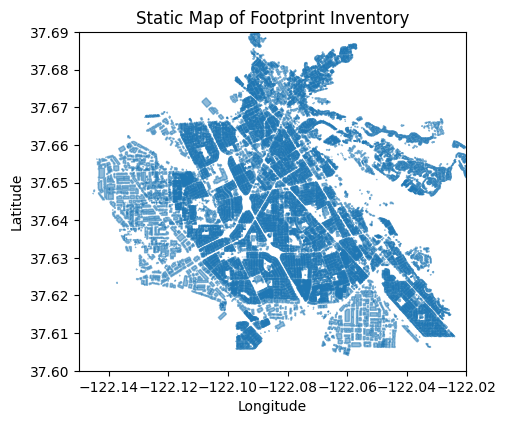

JSON File Saved


In [26]:
# Create baseline inventory 
ftpt_inv = footprints.copy()
orig_inv_length = len(ftpt_inv)
points0['National_Flag'] = 1

# Merge unique footprint information in with baseline footprint inventory and perform checks for dropped points
ftpt_inv = ftpt_inv.merge(points0, left_on='FootprintID', right_on='POINT_FootprintID', how='left')
if len(ftpt_inv) != orig_inv_length: 
    raise ValueError('Footprints Dropped - Step 1')

if len(ftpt_inv[ftpt_inv['National_Flag']==1]) != len(points0): 
    raise ValueError('Footprints Dropped - Step 2')

# Drop redundant footprint column
ftpt_inv = ftpt_inv.drop(columns = ['POINT_FootprintID'])
ftpt_inv['National_Flag'] = ftpt_inv['National_Flag'].fillna(0)

# Plot inventory
fig, ax = plt.subplots(figsize=(5,5))
ftpt_inv.to_crs(crs_plot).plot(ax=ax, color='tab:blue', edgecolor='tab:blue', alpha=0.5, label = 'All Footprints')
plt.title('Static Map of Footprint Inventory')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(xbounds)
plt.ylim(ybounds)
plt.show()

# Export footprint inventory 
fxns.gdf_to_json(ftpt_inv, dir_attribution + 'National_Inventory_Polygon_AugmentedFtpt.json')

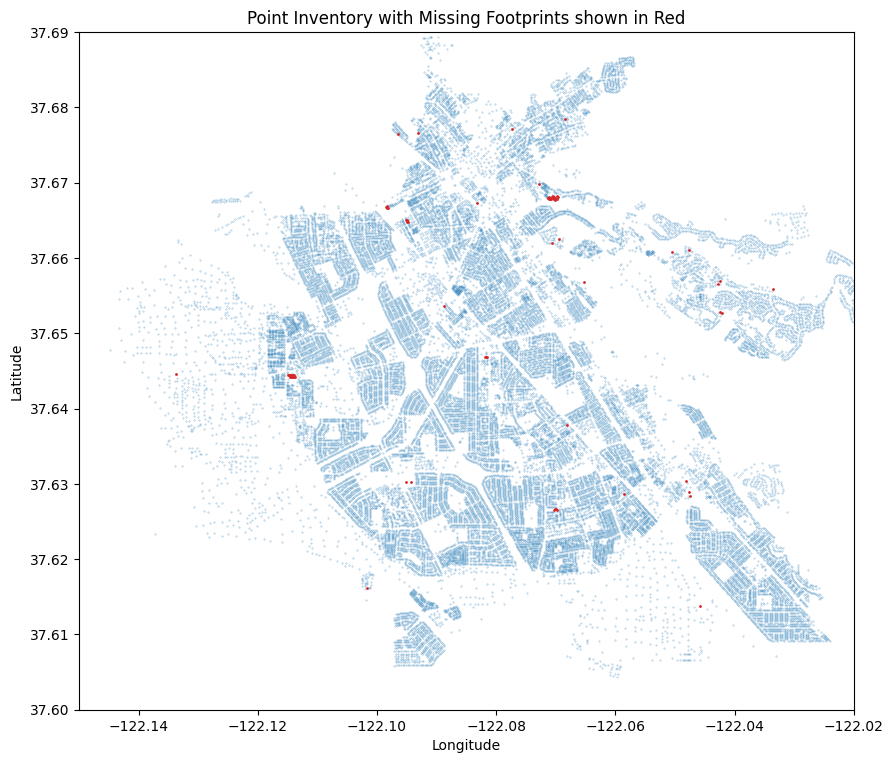

JSON File Saved


In [27]:
# Modify footprint inventory geometry to be the centroid of each footprint 
ftpt_inv = ftpt_inv.rename(columns={'geometry': 'ftpt_geometry'})
ftpt_inv['geometry'] = ftpt_inv['ftpt_geometry'].centroid
ftpt_inv.set_geometry('geometry')
ftpt_inv['Footprint_Flag'] = 1

# Drop ftpt_geometry for cases where footprints were augemented as circles, but did not exist 
no_ftpt_idx = ftpt_inv[ftpt_inv['FootprintID'] >= 100000].index
ftpt_inv.loc[no_ftpt_idx,'Footprint_Flag'] = 0
ftpt_inv.loc[no_ftpt_idx,'ftpt_geometry'] = np.nan

# Plot inventory
fig, ax = plt.subplots(figsize=(10, 10))
scraped = ftpt_inv[ftpt_inv['National_Flag']>0]
scraped[scraped['Footprint_Flag']==1].to_crs(crs_plot).plot(ax=ax, color='tab:blue', alpha = 0.5, markersize=0.1)
scraped[scraped['Footprint_Flag']==0].to_crs(crs_plot).plot(ax=ax, color='tab:red', markersize=1)
plt.title('Point Inventory with Missing Footprints shown in Red')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(xbounds)
plt.ylim(ybounds)
plt.show()

# Save inventory 
fxns.gdf_to_json(ftpt_inv, dir_attribution + 'National_Inventory_Point_AugmentedFtpt.json')

## **Clean Inventory Data and Prepare for Future Use**

In [28]:
# Load Inventory to Clean 
inventory = fxns.json_to_gdf(dir_attribution + 'National_Inventory_Point_AugmentedFtpt.json', crs_main) 

# Convert numeric, single-entry columns to appropriate type 
float_columns = ['NSI_ContentValue', 'NSI_StructureValue', 'NSI_ReplacementCost','NSI_PopOver65_Night',
                 'NSI_PopUnder65_Night', 'NSI_Population_Night', 'NSI_PopOver65_Day', 'NSI_PopUnder65_Day', 'NSI_Population_Day']
int_columns = ['FootprintID', 'POINT_NumPoints', 'POINT_MergeFlag', 'NSI_MinResUnits', 'NSI_MaxResUnits']   

# Convert columns to appropriate type 
for col in float_columns:
    inventory[col] = inventory[col].astype(float)
for col in int_columns:
    inventory[col] = inventory[col].fillna(0)
    inventory[col] = inventory[col].astype(int)


In [29]:
# Export
fxns.gdf_to_json(inventory, dir_attribution + 'National_Inventory_Final.json')

JSON File Saved
